# Delivery Performance Analysis

## Business Objective

Analyze delivery performance across the Olist e-commerce operation to understand:

- How frequently orders are delivered late
- How severe delivery delays are
- How delivery performance varies over time
- Which states/geographies experience higher delays
- How seller performance relates to delivery reliability
- Whether freight cost and order characteristics are associated with delays
- How delivery performance affects customer review scores

The analysis is performed at the order level.

## Business Question

Where are delivery problems occurring, how severe are they, and which operational dimensions should be prioritized for intervention?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [1]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"localhost\SQLEXPRESS"
database = "SupplyChainAnalytics"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" +
    quote_plus(connection_string)
)

Load the order-level dataset

In [3]:
query = """
SELECT *
FROM dbo.order_analytics
"""

df = pd.read_sql(query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 99441
Columns: 40


,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,payment_type_count,total_payment_value,max_payment_installments,review_record_count,distinct_review_count,avg_review_score,min_review_score,max_review_score,processing_days,shipping_days,fulfillment_days,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,campos dos goytacazes,RJ,28013,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.00,1.00,1.00,58.90,13.29,72.19,1.00,1.00,72.19,2.00,1.00,1.00,5.00,5,5,0.03,6.37,7.61,15.63,-8.01,1,0,0,Early,No Delay,0,0,Low Value
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,santa fe do sul,SP,15775,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.00,1.00,1.00,239.90,19.93,259.83,1.00,1.00,259.83,3.00,1.00,1.00,4.00,4,4,0.01,8.15,16.22,18.55,-2.33,1,0,0,Early,No Delay,0,0,Medium Value
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,para de minas,MG,35661,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.00,1.00,1.00,199.00,17.87,216.87,1.00,1.00,216.87,5.00,1.00,1.00,5.00,5,5,0.01,1.91,7.95,21.39,-13.45,1,0,0,Early,No Delay,0,0,Medium Value
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,atibaia,SP,12952,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.00,1.00,1.00,12.99,12.79,25.78,1.00,1.00,25.78,2.00,1.00,1.00,4.00,4,4,0.01,2.14,6.15,11.58,-5.44,1,0,0,Early,No Delay,0,0,Low Value
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,varzea paulista,SP,13226,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.00,1.00,1.00,199.90,18.14,218.04,1.00,1.00,218.04,3.00,1.00,1.00,5.00,5,5,0.01,11.82,25.11,40.42,-15.30,1,0,0,Early,No Delay,0,0,Medium Value


Validating grain again

In [4]:
print("Total rows:", len(df))
print("Distinct orders:", df["order_id"].nunique())

Total rows: 99441
Distinct orders: 99441


In [5]:
assert len(df) == df["order_id"].nunique()

print("✓ Order-level grain validated")

✓ Order-level grain validated


Basic inspection

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   customer_unique_id             99441 non-null  str           
 3   order_status                   99441 non-null  str           
 4   customer_city                  99441 non-null  str           
 5   customer_state                 99441 non-null  str           
 6   customer_zip_code_prefix       99441 non-null  str           
 7   order_purchase_timestamp       99441 non-null  datetime64[us]
 8   order_approved_at              99281 non-null  datetime64[us]
 9   order_delivered_carrier_date   97658 non-null  datetime64[us]
 10  order_delivered_customer_date  96476 non-null  datetime64[us]
 11  order_estimated_delivery_d

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99441,99441,00010242fe8c5a6d1ba2dd792cb16214,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,3ce436f183e68e07877b285a838db11a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441,14994,22790,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278,2016-10-08 10:34:01,2017-09-15 22:28:50.250000,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28,NaN


In [8]:
df.isna().sum().sort_values(ascending=False)

delay_days                       2965
fulfillment_days                 2965
order_delivered_customer_date    2965
shipping_days                    1797
order_delivered_carrier_date     1783
order_item_count                  775
seller_count                      775
product_count                     775
total_order_value                 775
order_item_value                  775
freight_value                     775
review_record_count               768
avg_review_score                  768
distinct_review_count             768
max_review_score                  768
min_review_score                  768
processing_days                   160
order_approved_at                 160
payment_type_count                  1
max_payment_installments            1
payment_record_count                1
total_payment_value                 1
customer_id                         0
order_id                            0
order_purchase_timestamp            0
customer_zip_code_prefix            0
customer_sta

## 1. Overall Delivery Performance

First, establish the baseline delivery performance of the marketplace.

Key metrics:

- Total orders
- Delivered orders
- Late orders
- On-time/early orders
- Undelivered orders
- Late delivery rate

In [9]:
total_orders = len(df)
total_orders = len(df)

delivered_orders = df["is_delivered"].sum()

late_orders = df["is_late"].sum()

not_delivered = (df["is_delivered"] == 0).sum()

late_rate = (
    late_orders / delivered_orders * 100
    if delivered_orders > 0 else 0
)

print(f"Total orders: {total_orders:,}")
print(f"Delivered orders: {delivered_orders:,}")
print(f"Late orders: {late_orders:,}")
print(f"Not delivered: {not_delivered:,}")
print(f"Late delivery rate: {late_rate:.2f}%")

Total orders: 99,441
Delivered orders: 96,476
Late orders: 7,827
Not delivered: 2,965
Late delivery rate: 8.11%


Delivery category distribution

In [10]:
delivery_distribution = (
    df["delivery_performance_category"]
    .value_counts()
    .reset_index()
)

delivery_distribution.columns = [
    "delivery_category",
    "order_count"
]

delivery_distribution["percentage"] = (
    delivery_distribution["order_count"]
    / len(df) * 100
)

delivery_distribution

,delivery_category,order_count,percentage
0,Early,88649,89.15
1,Late,7827,7.87
2,Not Delivered,2965,2.98


Chart


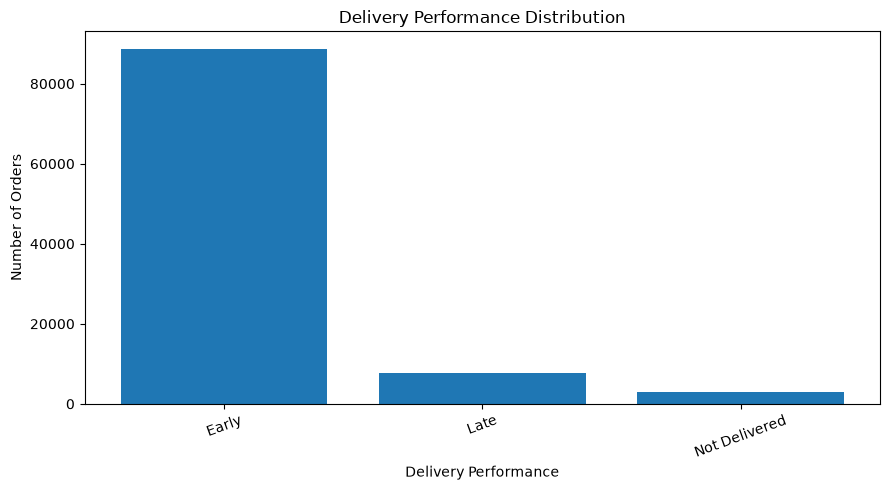

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(
    delivery_distribution["delivery_category"],
    delivery_distribution["order_count"]
)

plt.title("Delivery Performance Distribution")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#Most orders are delivered successfully, but a meaningful minority experience delays, while a smaller group remains undelivered.

Delay severity

In [12]:
severity = (
    df["delay_severity"]
    .value_counts()
    .reset_index()
)

severity.columns = [
    "delay_severity",
    "order_count"
]

severity["percentage"] = (
    severity["order_count"] / len(df) * 100
)

severity

,delay_severity,order_count,percentage
0,No Delay,88649,89.15
1,Severe Delay,3346,3.36
2,Not Delivered,2965,2.98
3,Minor Delay,2662,2.68
4,Moderate Delay,1819,1.83


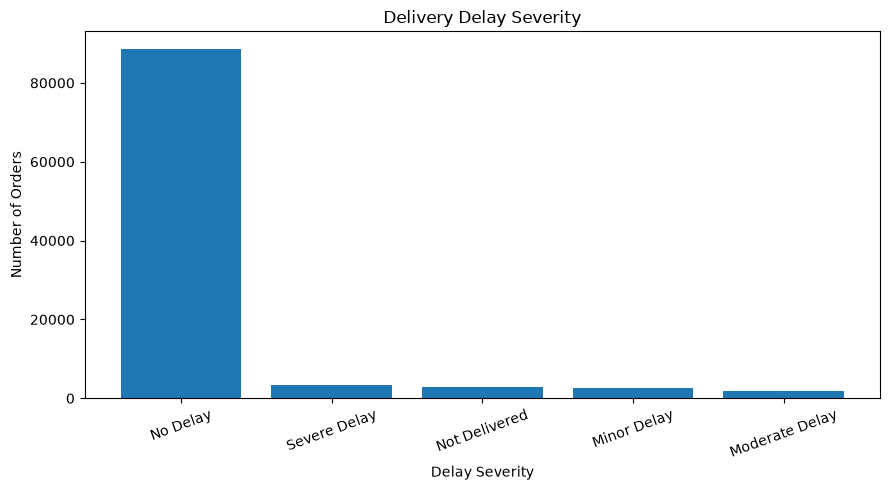

In [13]:
plt.figure(figsize=(9, 5))

plt.bar(
    severity["delay_severity"],
    severity["order_count"]
)

plt.title("Delivery Delay Severity")
plt.xlabel("Delay Severity")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 2. Delivery Time Distribution

Analyze fulfillment time and delay duration to understand the operational spread rather than relying only on averages.

In [14]:
df["fulfillment_days"].describe()
df["delay_days"].describe()

count   96,476.00
mean       -11.18
std         10.19
min       -146.02
25%        -16.24
50%        -11.95
75%         -6.39
max        188.97
Name: delay_days, dtype: float64

Fulfillment distribution

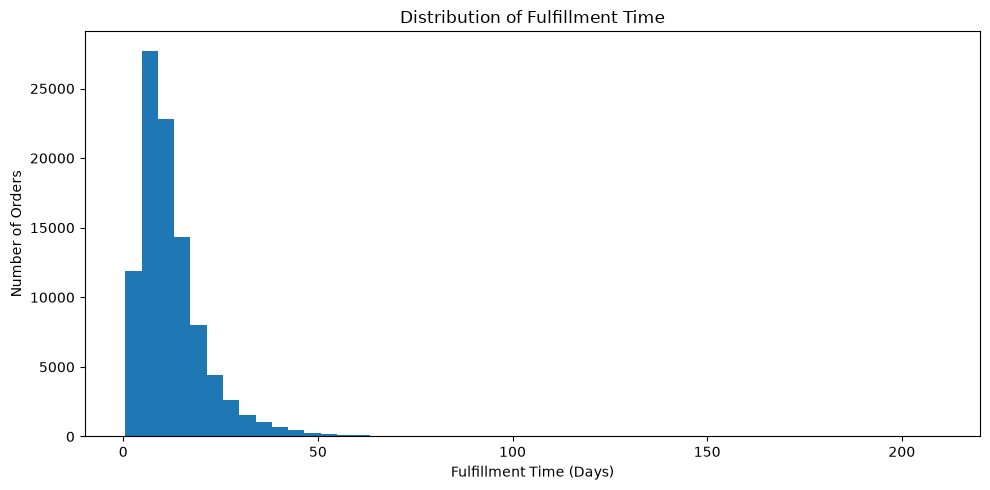

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[
        df["fulfillment_days"].notna() &
        (df["fulfillment_days"] >= 0),
        "fulfillment_days"
    ],
    bins=50
)

plt.title("Distribution of Fulfillment Time")
plt.xlabel("Fulfillment Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

Delay Distribution

In [16]:
late_df = df[
    (df["is_late"] == 1) &
    (df["delay_days"].notna())
].copy()

late_df["delay_days"].describe()

count   7,827.00
mean        9.55
std        13.95
min         0.00
25%         1.87
50%         5.81
75%        11.82
max       188.97
Name: delay_days, dtype: float64

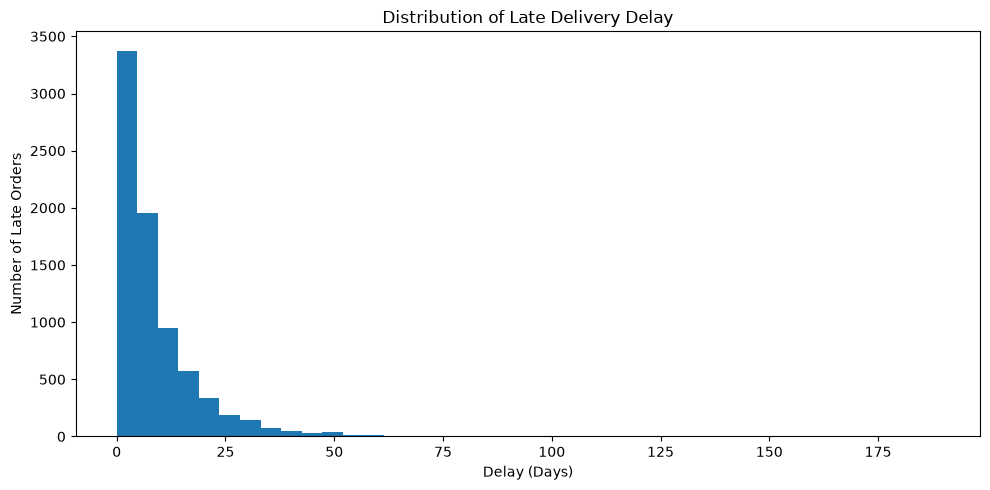

In [17]:
plt.figure(figsize=(10, 5))

plt.hist(
    late_df["delay_days"],
    bins=40
)

plt.title("Distribution of Late Delivery Delay")
plt.xlabel("Delay (Days)")
plt.ylabel("Number of Late Orders")

plt.tight_layout()
plt.show()

Delivery Performance Over Time

In [18]:
df["purchase_date"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

df["purchase_month"] = (
    df["purchase_date"]
    .dt.to_period("M")
    .astype(str)
)

df["purchase_year"] = df["purchase_date"].dt.year

Monthly delivery performance

In [19]:
monthly = (
    df.groupby("purchase_month")
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

monthly["late_rate"] = (
    monthly["late_orders"] /
    monthly["orders"] * 100
)

monthly

,purchase_month,orders,late_orders,late_rate
0,2016-09,4,1,25.00
1,2016-10,324,3,0.93
2,2016-12,1,0,0.00
3,2017-01,800,23,2.88
4,2017-02,1780,53,2.98
5,2017-03,2682,142,5.29
6,2017-04,2404,181,7.53
7,2017-05,3700,128,3.46
8,2017-06,3245,121,3.73
9,2017-07,4026,133,3.30


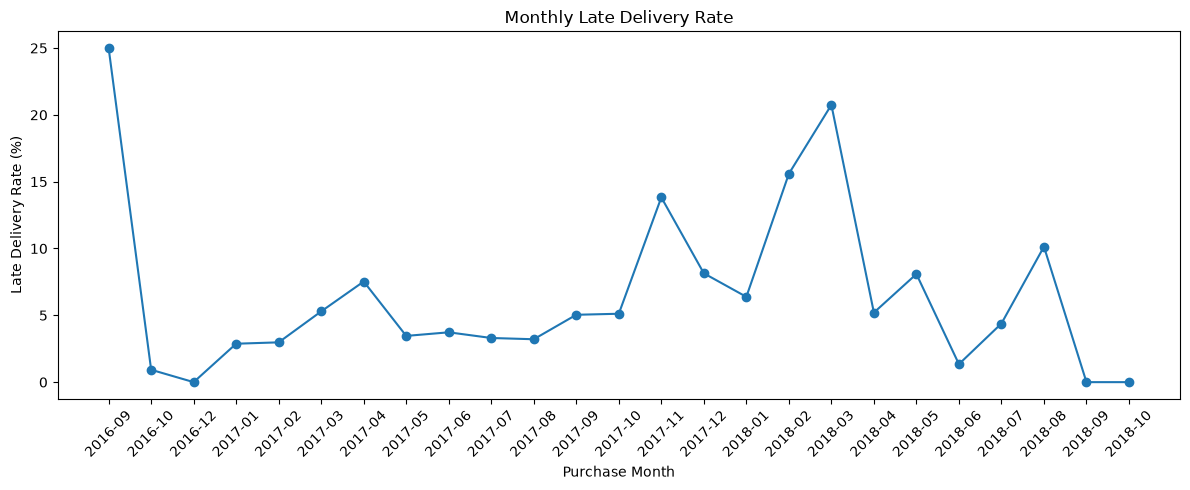

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["purchase_month"],
    monthly["late_rate"],
    marker="o"
)

plt.title("Monthly Late Delivery Rate")
plt.xlabel("Purchase Month")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Geographic Delivery Performance

Determine whether delivery reliability varies substantially across customer states.

This helps identify geographic regions where logistics capacity, transportation distance, seller distribution, or carrier coverage may contribute to SLA failures.

In [21]:
state_performance = (
    df.groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        avg_fulfillment_days=("fulfillment_days", "mean")
    )
    .reset_index()
)

state_late_delay = (
    df[df["is_late"] == 1]
    .groupby("customer_state")
    .agg(
        avg_late_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

state_performance = state_performance.merge(
    state_late_delay,
    on="customer_state",
    how="left"
)

state_performance["late_rate"] = (
    state_performance["late_orders"]
    / state_performance["orders"]
    * 100
)

state_performance = state_performance.sort_values(
    "late_rate",
    ascending=False
)

state_performance.head(15)

,customer_state,orders,late_orders,avg_fulfillment_days,avg_late_delay_days,late_rate
1,AL,413,95,24.54,9.25,23.00
9,MA,747,141,21.57,9.97,18.88
16,PI,495,76,19.46,12.30,15.35
5,CE,1336,196,21.27,14.33,14.67
24,SE,350,51,21.52,16.89,14.57
4,BA,3380,457,19.34,11.10,13.52
18,RJ,12852,1664,15.31,12.85,12.95
26,TO,280,35,17.66,5.65,12.50
7,ES,2033,244,15.79,10.60,12.00
13,PA,975,117,23.77,12.30,12.00


In [22]:
state_reliable = state_performance[
    state_performance["orders"] >= 100
].copy()

state_reliable.sort_values(
    "late_rate",
    ascending=False
).head(15)

,customer_state,orders,late_orders,avg_fulfillment_days,avg_late_delay_days,late_rate
1,AL,413,95,24.54,9.25,23.00
9,MA,747,141,21.57,9.97,18.88
16,PI,495,76,19.46,12.30,15.35
5,CE,1336,196,21.27,14.33,14.67
24,SE,350,51,21.52,16.89,14.57
4,BA,3380,457,19.34,11.10,13.52
18,RJ,12852,1664,15.31,12.85,12.95
26,TO,280,35,17.66,5.65,12.50
7,ES,2033,244,15.79,10.60,12.00
13,PA,975,117,23.77,12.30,12.00


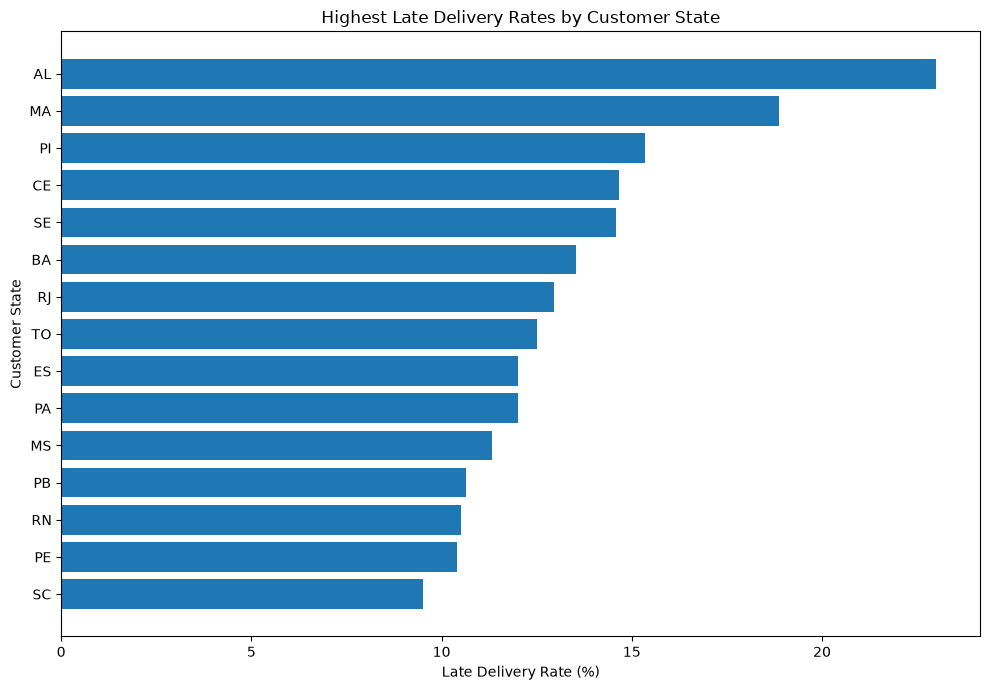

In [23]:
top_states = state_reliable.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states["customer_state"],
    top_states["late_rate"]
)

plt.title("Highest Late Delivery Rates by Customer State")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Seller Delivery Performance

Analyze whether delivery delays are concentrated among specific sellers.

Seller-level analysis can reveal operational concentration: a relatively small number of sellers may account for a disproportionate share of late deliveries.

In [24]:
seller_query = """
WITH seller_order AS (
    SELECT
        oi.seller_id,
        oi.order_id,
        SUM(oi.price) AS seller_item_value,
        SUM(oi.freight_value) AS seller_freight_value
    FROM dbo.raw_order_items oi
    GROUP BY
        oi.seller_id,
        oi.order_id
)

SELECT
    so.seller_id,

    COUNT(*) AS order_count,

    SUM(CASE
        WHEN oa.is_late = 1 THEN 1
        ELSE 0
    END) AS late_orders,

    CAST(
        100.0 * SUM(CASE
            WHEN oa.is_late = 1 THEN 1
            ELSE 0
        END) / NULLIF(COUNT(*), 0)
        AS DECIMAL(10,2)
    ) AS late_rate,

    AVG(oa.fulfillment_days) AS avg_fulfillment_days,

    AVG(so.seller_item_value) AS avg_item_value,

    AVG(so.seller_freight_value) AS avg_freight_value,

    SUM(so.seller_item_value) AS total_item_value,

    SUM(so.seller_freight_value) AS total_freight_value

FROM seller_order so

INNER JOIN dbo.order_analytics oa
    ON so.order_id = oa.order_id

GROUP BY
    so.seller_id

HAVING COUNT(*) >= 20

ORDER BY
    late_rate DESC;
"""

seller_df = pd.read_sql(seller_query, engine)

print("Sellers:", len(seller_df))
seller_df.head(10)

Sellers: 818


,seller_id,order_count,late_orders,late_rate,avg_fulfillment_days,avg_item_value,avg_freight_value,total_item_value,total_freight_value
0,f76a3b1349b6df1ee875d1f3fa4340f0,24,9,37.50,17.02,173.37,24.51,"4,160.79",588.19
1,ede0c03645598cdfc63ca8237acbe73d,46,15,32.61,18.59,54.75,16.34,"2,518.37",751.50
2,821fb029fc6e495ca4f08a35d51e53a5,28,9,32.14,16.79,685.26,55.46,"19,187.42","1,552.83"
3,7f152321c60a266edc53af1925ef96c1,20,6,30.00,23.47,195.99,27.61,"3,919.80",552.12
4,835f0f7810c76831d6c7d24c7a646d4d,44,13,29.55,18.10,116.59,21.91,"5,130.00",964.03
5,054694fa03fe82cec4b7551487331d74,21,6,28.57,30.79,475.39,34.32,"9,983.10",720.65
6,54965bbe3e4f07ae045b90b0b8541f52,78,22,28.21,26.17,140.53,28.25,"10,961.30","2,203.54"
7,4e5725ba188db8252977a4f0227bd462,22,6,27.27,20.97,87.75,17.39,"1,930.59",382.61
8,ad781527c93d00d89a11eecd9dcad7c1,44,12,27.27,25.50,156.81,54.08,"6,899.57","2,379.69"
9,66e0557ecc2b4dbea057e93f215f68d8,31,8,25.81,31.73,402.58,16.06,"12,480.00",497.99


In [25]:
worst_sellers = (
    seller_df
    .sort_values("late_rate", ascending=False)
    .head(15)
)

display(worst_sellers)

,seller_id,order_count,late_orders,late_rate,avg_fulfillment_days,avg_item_value,avg_freight_value,total_item_value,total_freight_value
0,f76a3b1349b6df1ee875d1f3fa4340f0,24,9,37.50,17.02,173.37,24.51,"4,160.79",588.19
1,ede0c03645598cdfc63ca8237acbe73d,46,15,32.61,18.59,54.75,16.34,"2,518.37",751.50
2,821fb029fc6e495ca4f08a35d51e53a5,28,9,32.14,16.79,685.26,55.46,"19,187.42","1,552.83"
3,7f152321c60a266edc53af1925ef96c1,20,6,30.00,23.47,195.99,27.61,"3,919.80",552.12
4,835f0f7810c76831d6c7d24c7a646d4d,44,13,29.55,18.10,116.59,21.91,"5,130.00",964.03
5,054694fa03fe82cec4b7551487331d74,21,6,28.57,30.79,475.39,34.32,"9,983.10",720.65
6,54965bbe3e4f07ae045b90b0b8541f52,78,22,28.21,26.17,140.53,28.25,"10,961.30","2,203.54"
7,4e5725ba188db8252977a4f0227bd462,22,6,27.27,20.97,87.75,17.39,"1,930.59",382.61
8,ad781527c93d00d89a11eecd9dcad7c1,44,12,27.27,25.50,156.81,54.08,"6,899.57","2,379.69"
9,66e0557ecc2b4dbea057e93f215f68d8,31,8,25.81,31.73,402.58,16.06,"12,480.00",497.99


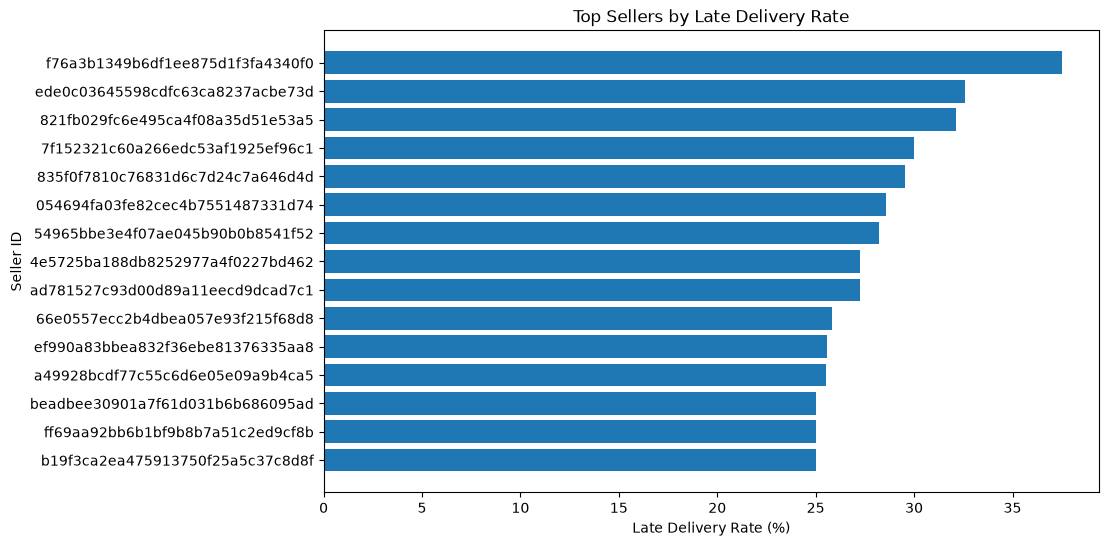

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    worst_sellers["seller_id"].astype(str),
    worst_sellers["late_rate"]
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")
plt.title("Top Sellers by Late Delivery Rate")

plt.gca().invert_yaxis()

plt.show()

In [27]:
high_volume_sellers = (
    seller_df
    .sort_values("order_count", ascending=False)
    .head(15)
)

display(
    high_volume_sellers[
        [
            "seller_id",
            "order_count",
            "late_rate",
            "avg_fulfillment_days",
            "avg_freight_value"
        ]
        if "avg_freight_value" in high_volume_sellers.columns
        else [
            "seller_id",
            "order_count",
            "late_rate",
            "avg_fulfillment_days",
            "avg_freight_value"
        ]
    ]
)

,seller_id,order_count,late_rate,avg_fulfillment_days,avg_freight_value
427,6560211a19b47992c3666cc44a7e94c0,1854,6.31,9.63,15.08
187,4a3ca9315b744ce9f8e9374361493884,1806,10.80,14.49,19.42
444,cc419e0650a3c5ba77189a1882b7556a,1706,5.92,11.59,15.05
199,1f50f920176fa81dab994f9023523100,1404,10.54,15.81,25.05
360,da8622b14eb17ae2831f4ac5b9dab84a,1314,7.61,11.19,18.99
359,955fee9216a65b617aa5c0531780ce60,1287,7.61,10.77,19.76
451,7a67c85e85bb2ce8582c35f2203ad736,1160,5.86,11.20,18.02
211,ea8482cd71df3c1969d7b9473ff13abc,1146,10.30,13.32,15.31
168,4869f7a5dfa277a7dca6462dcf3b52b2,1132,11.48,15.06,17.82
452,3d871de0142ce09b7081e2b9d1733cb1,1080,5.83,13.51,20.77


# delay affect customer experience?

In [28]:
review_analysis = (
    df[
        df["avg_review_score"].notna()
    ]
    .groupby("delivery_performance_category")
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

review_analysis

,delivery_performance_category,orders,avg_review_score
0,Early,88168,4.29
1,Late,7662,2.57
2,Not Delivered,2843,1.75


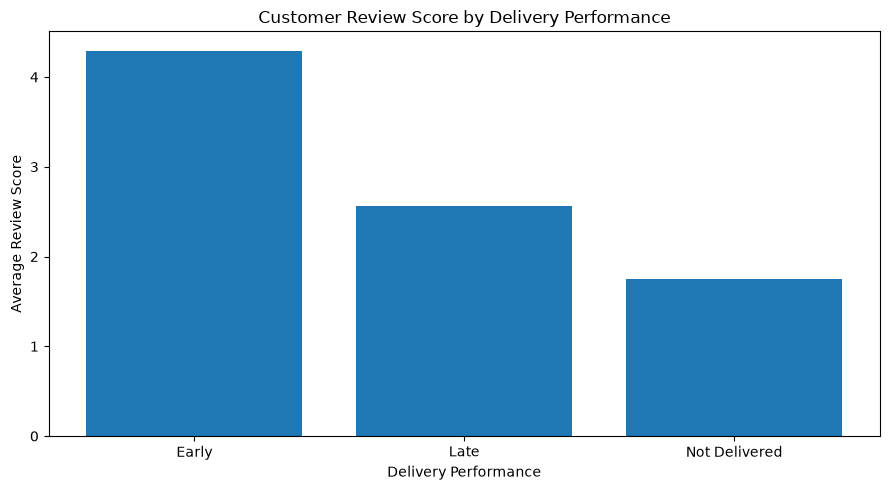

In [29]:

plt.figure(figsize=(9, 5))

plt.bar(
    review_analysis["delivery_performance_category"],
    review_analysis["avg_review_score"]
)

plt.title("Customer Review Score by Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

# Operational cost

In [30]:
freight_analysis = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_freight=("freight_value", "mean"),
        avg_order_value=("total_order_value", "mean"),
        avg_fulfillment=("fulfillment_days", "mean")
    )
    .reset_index()
)

freight_analysis

,is_late,orders,avg_freight,avg_order_value,avg_fulfillment
0,0,91614,22.67,159.53,10.88
1,1,7827,24.62,172.69,31.52


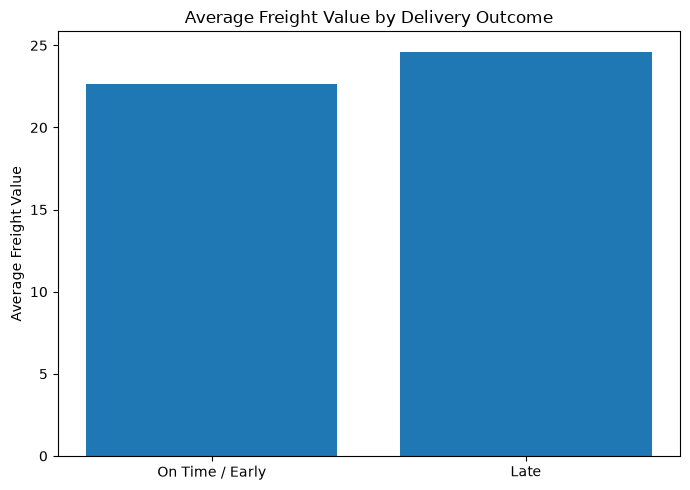

In [31]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["On Time / Early", "Late"],
    [
        freight_analysis.loc[
            freight_analysis["is_late"] == 0,
            "avg_freight"
        ].iloc[0],
        freight_analysis.loc[
            freight_analysis["is_late"] == 1,
            "avg_freight"
        ].iloc[0]
    ]
)

plt.title("Average Freight Value by Delivery Outcome")
plt.ylabel("Average Freight Value")

plt.tight_layout()
plt.show()

In [32]:
numeric_cols = [
    "order_item_count",
    "product_count",
    "seller_count",
    "order_item_value",
    "freight_value",
    "total_order_value",
    "payment_record_count",
    "total_payment_value",
    "processing_days",
    "shipping_days",
    "fulfillment_days",
    "delay_days",
    "avg_review_score",
    "is_late"
]

correlation = df[numeric_cols].corr()
correlation["is_late"].sort_values(ascending=False)

is_late                 1.00
delay_days              0.60
fulfillment_days        0.59
shipping_days           0.21
freight_value           0.02
processing_days         0.02
total_order_value       0.02
total_payment_value     0.02
order_item_value        0.01
payment_record_count   -0.00
order_item_count       -0.02
product_count          -0.02
seller_count           -0.03
avg_review_score       -0.33
Name: is_late, dtype: float64

## 7. Customer Experience and Delivery Performance

This section examines whether delivery performance is associated with customer review outcomes.

The analysis compares review scores between late and non-late deliveries and evaluates whether increasing delivery delays are associated with poorer customer experience.

In [33]:
review_distribution = (
    df["avg_review_score"]
    .value_counts(dropna=False)
    .sort_index()
)

display(review_distribution)

avg_review_score
1.00    11316
1.50        8
2.00     3125
2.50       34
3.00     8136
3.33        1
3.50       25
4.00    19018
4.33        1
4.50       54
5.00    56955
NaN       768
Name: count, dtype: int64

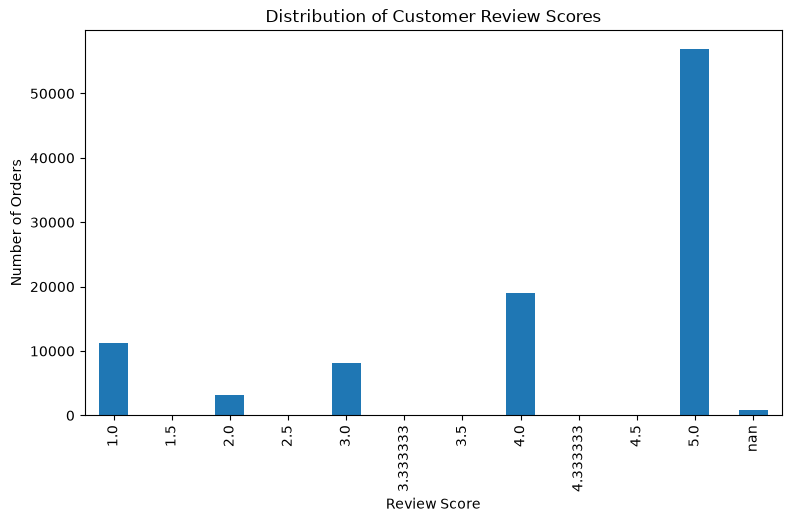

In [36]:
plt.figure(figsize=(9, 5))

review_distribution.plot(kind='bar')

plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.title("Distribution of Customer Review Scores")

plt.show()

# Late vs On-Time Review Score

In [37]:
review_by_delivery = (
    df[df["avg_review_score"].notna()]
    .groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

review_by_delivery["delivery_type"] = review_by_delivery["is_late"].map({
    0: "On-Time",
    1: "Late"
})

display(review_by_delivery)

,is_late,orders,avg_review_score,delivery_type
0,0,91011,4.21,On-Time
1,1,7662,2.57,Late


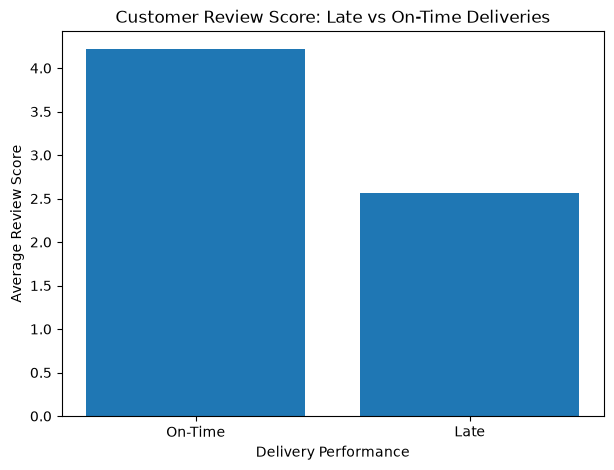

In [38]:
plt.figure(figsize=(7, 5))

plt.bar(
    review_by_delivery["delivery_type"],
    review_by_delivery["avg_review_score"]
)

plt.xlabel("Delivery Performance")
plt.ylabel("Average Review Score")
plt.title("Customer Review Score: Late vs On-Time Deliveries")

plt.show()

# Review Score by Delay Severity

In [39]:
review_by_severity = (
    df[df["avg_review_score"].notna()]
    .groupby("delay_severity")
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

display(review_by_severity)

,delay_severity,orders,avg_review_score
0,Minor Delay,2636,3.77
1,Moderate Delay,1773,2.32
2,No Delay,88168,4.29
3,Not Delivered,2843,1.75
4,Severe Delay,3253,1.73


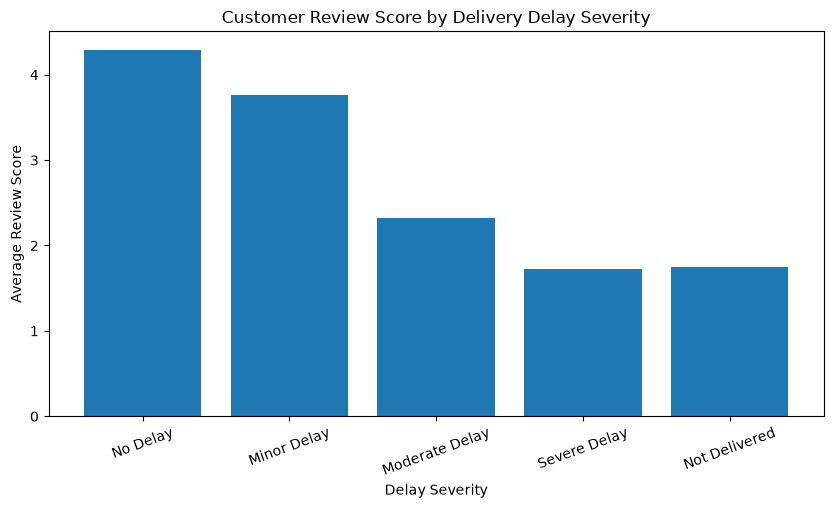

In [40]:
severity_order = [
    "No Delay",
    "Minor Delay",
    "Moderate Delay",
    "Severe Delay",
    "Not Delivered"
]

review_by_severity["delay_severity"] = pd.Categorical(
    review_by_severity["delay_severity"],
    categories=severity_order,
    ordered=True
)

review_by_severity = review_by_severity.sort_values(
    "delay_severity"
)

plt.figure(figsize=(10, 5))

plt.bar(
    review_by_severity["delay_severity"].astype(str),
    review_by_severity["avg_review_score"]
)

plt.xlabel("Delay Severity")
plt.ylabel("Average Review Score")
plt.title("Customer Review Score by Delivery Delay Severity")

plt.xticks(rotation=20)

plt.show()

## 8. Order Characteristics and Delivery Performance

This section examines whether order complexity and order economics are associated with delivery performance.

In [41]:
order_size_analysis = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_items=("order_item_count", "mean"),
        avg_products=("product_count", "mean"),
        avg_sellers=("seller_count", "mean")
    )
    .reset_index()
)

order_size_analysis["delivery_type"] = order_size_analysis["is_late"].map({
    0: "On-Time",
    1: "Late"
})

display(order_size_analysis)

,is_late,orders,avg_items,avg_products,avg_sellers,delivery_type
0,0,91614,1.14,1.04,1.01,On-Time
1,1,7827,1.11,1.02,1.00,Late


# Order Value Analysis

In [42]:
value_analysis = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_order_value=("total_order_value", "mean"),
        median_order_value=("total_order_value", "median"),
        avg_item_value=("order_item_value", "mean")
    )
    .reset_index()
)

value_analysis["delivery_type"] = value_analysis["is_late"].map({
    0: "On-Time",
    1: "Late"
})

display(value_analysis)

,is_late,orders,avg_order_value,median_order_value,avg_item_value,delivery_type
0,0,91614,159.53,104.79,136.87,On-Time
1,1,7827,172.69,112.20,148.07,Late


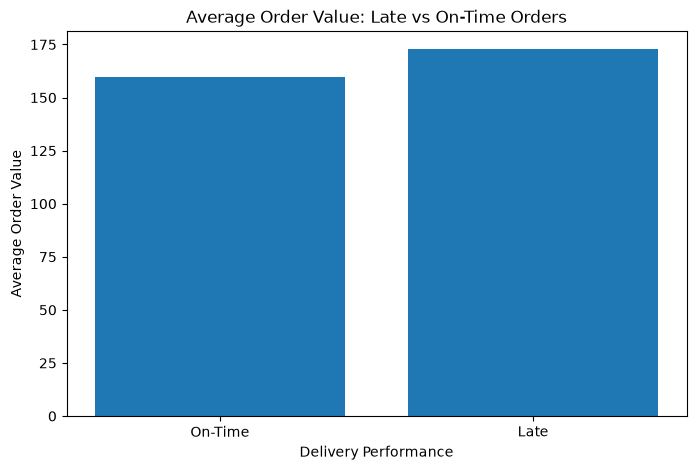

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    value_analysis["delivery_type"],
    value_analysis["avg_order_value"]
)

plt.xlabel("Delivery Performance")
plt.ylabel("Average Order Value")
plt.title("Average Order Value: Late vs On-Time Orders")

plt.show()

## 9. Freight Cost and Delivery Performance

This section evaluates the relationship between freight cost, order economics, and delivery performance.

In [44]:
freight_analysis = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_freight=("freight_value", "mean"),
        median_freight=("freight_value", "median"),
        avg_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

freight_analysis["delivery_type"] = freight_analysis["is_late"].map({
    0: "On-Time",
    1: "Late"
})

display(freight_analysis)

,is_late,orders,avg_freight,median_freight,avg_order_value,delivery_type
0,0,91614,22.67,17.07,159.53,On-Time
1,1,7827,24.62,18.05,172.69,Late


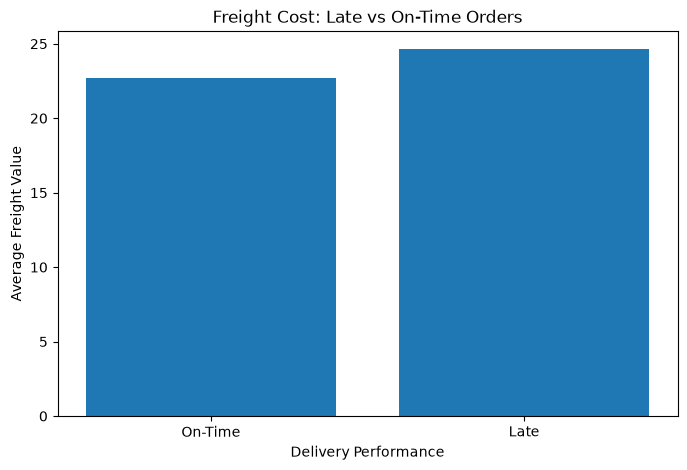

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    freight_analysis["delivery_type"],
    freight_analysis["avg_freight"]
)

plt.xlabel("Delivery Performance")
plt.ylabel("Average Freight Value")
plt.title("Freight Cost: Late vs On-Time Orders")

plt.show()

Freight Burden

In [46]:
df["freight_ratio"] = np.where(
    df["order_item_value"] > 0,
    df["freight_value"] / df["order_item_value"],
    np.nan
)

In [47]:
freight_ratio_analysis = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_freight_ratio=("freight_ratio", "mean"),
        median_freight_ratio=("freight_ratio", "median")
    )
    .reset_index()
)

freight_ratio_analysis["delivery_type"] = (
    freight_ratio_analysis["is_late"]
    .map({
        0: "On-Time",
        1: "Late"
    })
)

display(freight_ratio_analysis)

,is_late,orders,avg_freight_ratio,median_freight_ratio,delivery_type
0,0,91614,0.31,0.22,On-Time
1,1,7827,0.32,0.23,Late


## 10. Operational Driver Exploration

This section compares major operational characteristics between late and on-time orders to identify candidate drivers for further statistical testing.

In [48]:
driver_summary = (
    df.groupby("is_late")
    .agg(
        orders=("order_id", "count"),
        avg_fulfillment_days=("fulfillment_days", "mean"),
        avg_items=("order_item_count", "mean"),
        avg_products=("product_count", "mean"),
        avg_sellers=("seller_count", "mean"),
        avg_order_value=("total_order_value", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_freight_ratio=("freight_ratio", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
    .reset_index()
)

driver_summary["delivery_type"] = driver_summary["is_late"].map({
    0: "On-Time",
    1: "Late"
})

display(driver_summary)

,is_late,orders,avg_fulfillment_days,avg_items,avg_products,avg_sellers,avg_order_value,avg_freight,avg_freight_ratio,avg_review_score,delivery_type
0,0,91614,10.88,1.14,1.04,1.01,159.53,22.67,0.31,4.21,On-Time
1,1,7827,31.52,1.11,1.02,1.00,172.69,24.62,0.32,2.57,Late


# correlation

In [49]:
correlation_cols = [
    "fulfillment_days",
    "order_item_count",
    "product_count",
    "seller_count",
    "order_item_value",
    "freight_value",
    "total_order_value",
    "payment_record_count",
    "max_payment_installments",
    "avg_review_score"
]

corr = df[correlation_cols].corr()

display(corr)

,fulfillment_days,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,max_payment_installments,avg_review_score
fulfillment_days,1.00,-0.02,-0.03,-0.04,0.06,0.17,0.07,0.00,0.05,-0.33
order_item_count,-0.02,1.00,0.47,0.28,0.15,0.44,0.19,-0.00,0.07,-0.12
product_count,-0.03,0.47,1.00,0.59,0.06,0.19,0.08,0.00,0.07,-0.10
seller_count,-0.04,0.28,0.59,1.00,0.04,0.13,0.05,0.01,0.06,-0.11
order_item_value,0.06,0.15,0.06,0.04,1.00,0.41,1.00,0.00,0.31,-0.04
freight_value,0.17,0.44,0.19,0.13,0.41,1.00,0.49,0.01,0.20,-0.09
total_order_value,0.07,0.19,0.08,0.05,1.00,0.49,1.00,0.00,0.32,-0.05
payment_record_count,0.00,-0.00,0.00,0.01,0.00,0.01,0.00,1.00,-0.04,-0.00
max_payment_installments,0.05,0.07,0.07,0.06,0.31,0.20,0.32,-0.04,1.00,-0.03
avg_review_score,-0.33,-0.12,-0.10,-0.11,-0.04,-0.09,-0.05,-0.00,-0.03,1.00


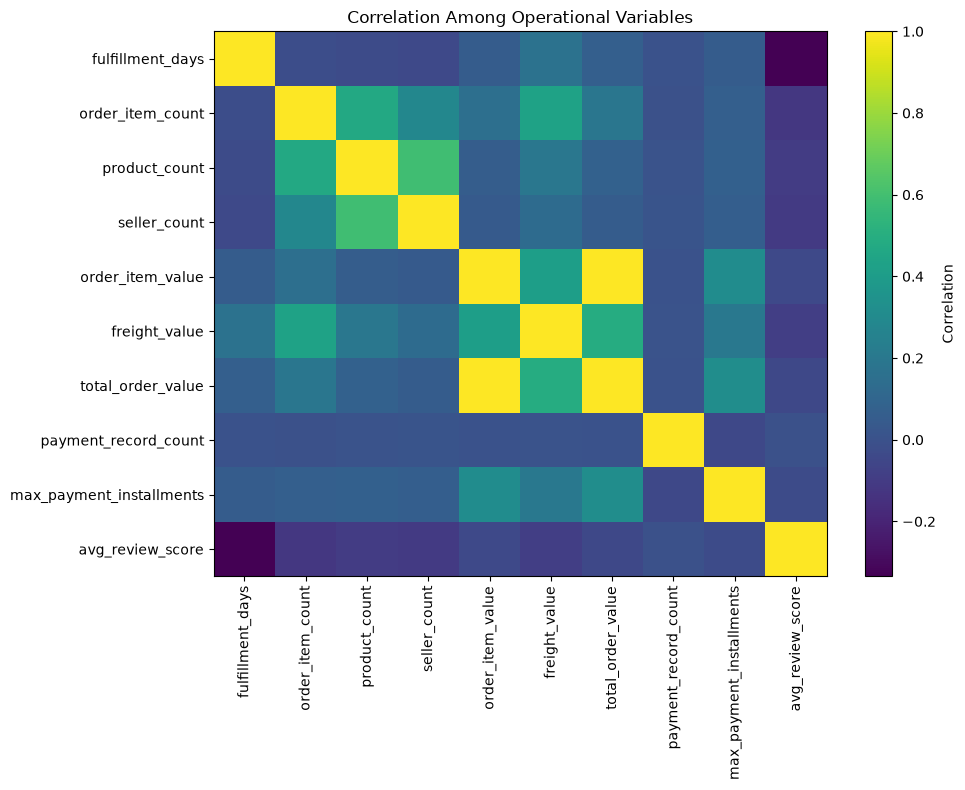

In [50]:
plt.figure(figsize=(10, 8))

plt.imshow(corr, aspect="auto")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Among Operational Variables")

plt.tight_layout()
plt.show()

## Key Findings from Delivery Analysis

### Delivery Reliability

The overall analysis establishes the baseline delivery performance and quantifies the proportion of delivered orders that missed the promised delivery date.

### Delay Severity

Late deliveries vary substantially in severity. A relatively small number of orders experience extremely large delays, indicating the presence of operational outliers that may require separate investigation.

### Geographic Variation

Delivery performance varies across customer and seller locations. States with sufficiently large order volumes can be compared to identify geographic areas requiring operational attention.

### Seller Performance

Seller-level analysis identifies high-volume sellers with disproportionately high late-delivery rates. These sellers represent potential intervention targets because improving their performance could affect a meaningful number of orders.

### Customer Experience

Delivery performance is associated with customer review outcomes. The relationship between delay severity and review score will be formally tested in the statistical analysis stage.

### Order Complexity

Order characteristics such as item count, product count, and number of sellers provide candidate operational factors that may contribute to fulfillment complexity.

### Cost

Freight value and freight burden provide additional dimensions for evaluating delivery performance and operational efficiency.

### Next Step

The descriptive analysis identifies candidate relationships but does not establish statistical significance or causality. The next stage will use statistical testing and regression to determine which operational factors are significantly associated with delivery delays.